(8693, 14) (4277, 13)
  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        False  
3        False

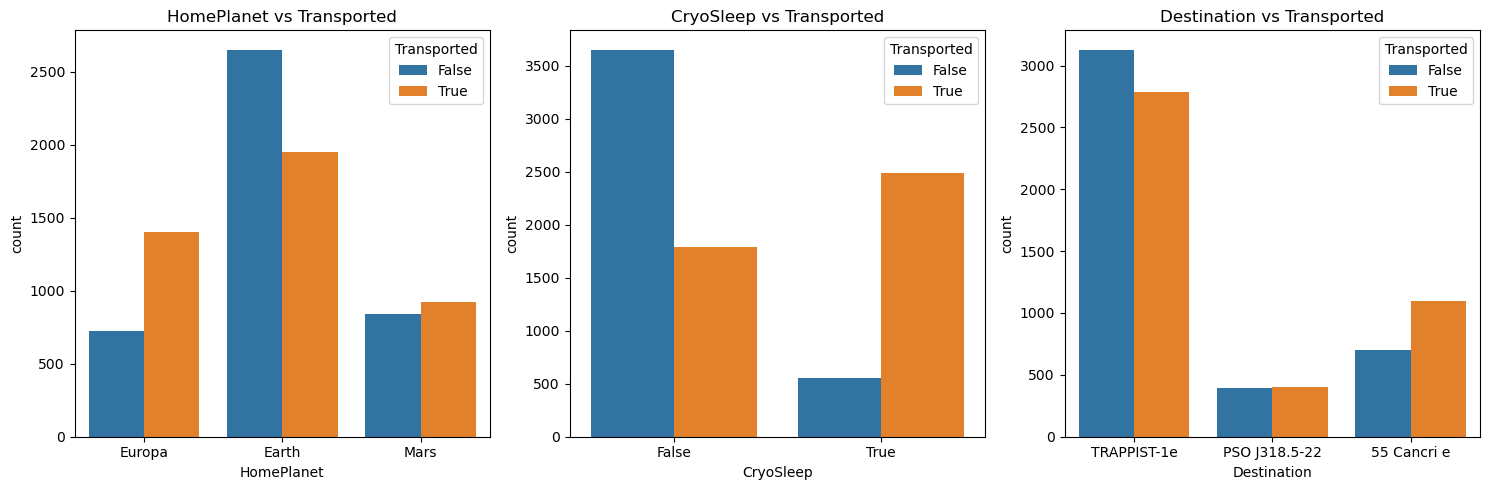

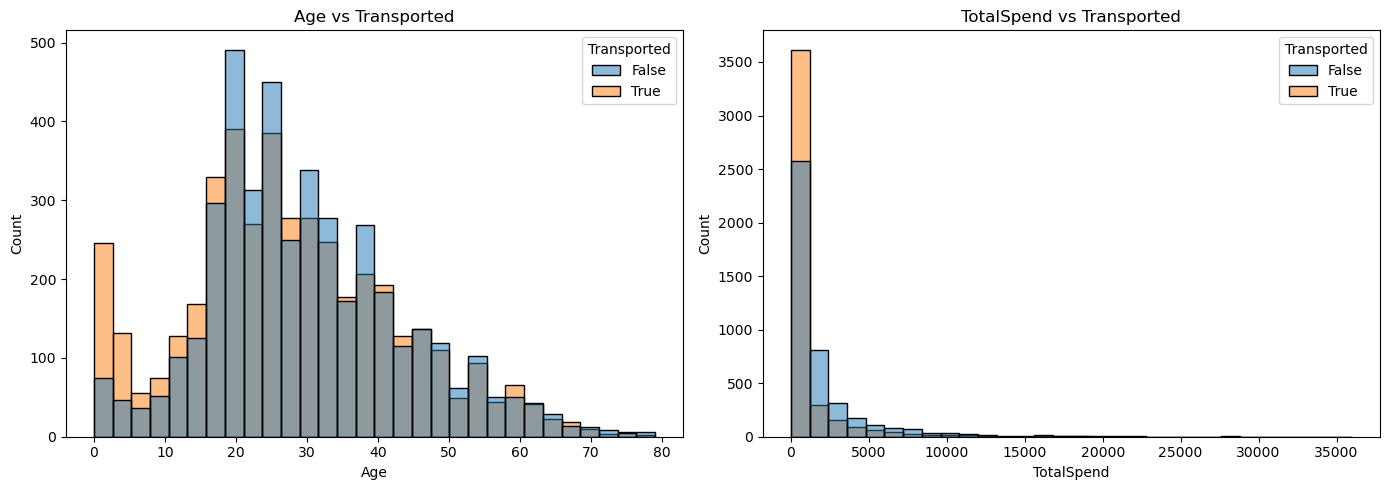

['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'TotalSpend', 'Deck', 'CabinNum', 'Side']
CryoSleep
False    2248.299687
True        0.000000
Name: TotalSpend, dtype: float64
NoSpend  Transported
0        False          0.701389
         True           0.298611
1        True           0.786477
         False          0.213523
Name: proportion, dtype: float64
HomePlanet        0
CryoSleep         0
Destination       0
Age             179
VIP               0
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Transported       0
TotalSpend        0
Deck              0
CabinNum        199
Side              0
IsChild           0
NoSpend           0
dtype: int64
   HomePlanet  CryoSleep  Destination   Age  VIP  RoomService  FoodCourt  \
0           1          0            2  39.0    0          0.0        0.0   
1           0          0            2  24.0    0 

In [13]:
import pandas as pd #표 다루는 도구 소환
import numpy as np #숫자 계산 도구 소한
import matplotlib.pyplot as plt #표 그리는 도구소환 바로 아래것도 같음
import seaborn as sns
from xgboost import XGBClassifier

train = pd.read_csv('train.csv') #각각의 cvs파일 변수에 저장
test = pd.read_csv('test.csv')

print(train.shape, test.shape)# 데이터 크기 확인하고 첫 5행 실행
print(train.head())
print(train.isnull().sum()) #결측치 확인
print(train['Transported'].value_counts()) # Transported

fig, axes = plt.subplots(1, 3, figsize=(15, 5)) # 그래프 그릴 공간 만듬

sns.countplot(x='HomePlanet', hue='Transported', data=train, ax=axes[0])# 출발 행성별 이동 여부 그래프
axes[0].set_title('HomePlanet vs Transported')

sns.countplot(x='CryoSleep', hue='Transported', data=train, ax=axes[1])# 냉동 수면 여부별 이동 여부
axes[1].set_title('CryoSleep vs Transported')

sns.countplot(x='Destination', hue='Transported', data=train, ax=axes[2])# 목적지별 이동 여부
axes[2].set_title('Destination vs Transported')

plt.tight_layout()#그래프 출력
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=train, x='Age', hue='Transported', bins=30, ax=axes[0])# 나이별 사람수 막대 
axes[0].set_title('Age vs Transported')

spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'] #5개 지출 컬럼 전부 더해서 TotalSpend라는 새컬럼 생성
train['TotalSpend'] = train[spend_cols].sum(axis=1)
sns.histplot(data=train, x='TotalSpend', hue='Transported', bins=30, ax=axes[1])
axes[1].set_title('TotalSpend vs Transported')

plt.tight_layout()
plt.show()

# Cabin 컬럼 분리 (deck/num/side)
train[['Deck', 'CabinNum', 'Side']] = train['Cabin'].str.split('/', expand=True)
test[['Deck', 'CabinNum', 'Side']] = test['Cabin'].str.split('/', expand=True)

# 필요없는 컬럼 제거
train = train.drop(['PassengerId', 'Cabin', 'Name'], axis=1)
test_ids = test['PassengerId']
test = test.drop(['PassengerId', 'Cabin', 'Name'], axis=1)

print(train.columns.tolist())

# 어린이 여부 (예: 12살 이하)
train['IsChild'] = (train['Age'] <= 12).astype(int)
test['IsChild'] = (test['Age'] <= 12).astype(int)

spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
test['TotalSpend'] = test[spend_cols].sum(axis=1)

# CabinNum 숫자로 변환
train['CabinNum'] = pd.to_numeric(train['CabinNum'], errors='coerce')
test['CabinNum'] = pd.to_numeric(test['CabinNum'], errors='coerce')

train['NoSpend'] = (train['TotalSpend'] == 0).astype(int)
test['NoSpend'] = (test['TotalSpend'] == 0).astype(int)

print(train.groupby('CryoSleep')['TotalSpend'].mean())
print(train.groupby('NoSpend')['Transported'].value_counts(normalize=True))


# 비율대로 결측치 채우기
def fill_by_ratio(df, col, reference_df=None):
    if reference_df is None:
        reference_df = df
    value_counts = reference_df[col].value_counts(normalize=True)
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        fill_values = np.random.choice(
            value_counts.index,
            size=missing_count,
            p=value_counts.values
        )
        df.loc[df[col].isnull(), col] = fill_values
    return df

cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']
for col in cat_cols:
    train = fill_by_ratio(train, col)
    test = fill_by_ratio(test, col, reference_df=train)

print(train.isnull().sum())

# 문자형 컬럼 숫자로 변환
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']
for col in cat_cols:
    train[col] = le.fit_transform(train[col].astype(str))
    test[col] = le.fit_transform(test[col].astype(str))

print(train.head())

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 타겟이랑 특성 분리
X = train.drop('Transported', axis=1)
y = train['Transported']

# 훈련/검증 분리
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 모델 학습
xgb_model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# 검증 정확도 확인
y_pred = xgb_model.predict(X_val)
print("정확도:", accuracy_score(y_val, y_pred))

# 컬럼 순서 맞추기
feature_cols = X_train.columns.tolist()
test_pred = xgb_model.predict(test[feature_cols])

submission = pd.read_csv('sample_submission.csv')
submission['Transported'] = test_pred.astype(bool)
submission.to_csv('submission.csv', index=False)
print("완료!!")